In [33]:
import os
import random

dataset_path = r"D:\projects\RPPG\DATASET_2"

# Get all subjects
subjects = [
    name for name in os.listdir(dataset_path)
    if name.startswith("subject")
    and os.path.isdir(os.path.join(dataset_path, name))
]

# Sort numerically
subjects.sort(key=lambda x: int(x.replace("subject", "")))

# Reproducible shuffle
random.seed(42)
random.shuffle(subjects)

# 29 train, 6 validation, 7 test
train_subjects = subjects[:29]
val_subjects = subjects[29:35]
test_subjects = subjects[35:]

print("Total:", len(subjects))
print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))

print("\nTrain:", train_subjects)
print("\nValidation:", val_subjects)
print("\nTest:", test_subjects)

Total: 42
Train: 29
Validation: 6
Test: 7

Train: ['subject13', 'subject5', 'subject14', 'subject34', 'subject45', 'subject24', 'subject47', 'subject33', 'subject8', 'subject41', 'subject30', 'subject15', 'subject37', 'subject27', 'subject16', 'subject32', 'subject43', 'subject44', 'subject40', 'subject17', 'subject31', 'subject26', 'subject36', 'subject46', 'subject38', 'subject25', 'subject22', 'subject49', 'subject42']

Validation: ['subject39', 'subject1', 'subject4', 'subject35', 'subject9', 'subject10']

Test: ['subject12', 'subject18', 'subject20', 'subject23', 'subject3', 'subject11', 'subject48']


In [34]:
import os

split_dir = r"D:\projects\RPPG\splits"
os.makedirs(split_dir, exist_ok=True)

with open(os.path.join(split_dir, "train_subjects.txt"), "w") as f:
    f.write("\n".join(train_subjects))

with open(os.path.join(split_dir, "val_subjects.txt"), "w") as f:
    f.write("\n".join(val_subjects))

with open(os.path.join(split_dir, "test_subjects.txt"), "w") as f:
    f.write("\n".join(test_subjects))

print("Subject splits saved successfully.")

Subject splits saved successfully.


In [35]:
import os

subject_path = r"D:\projects\RPPG\DATASET_2\subject1"

print("Files:")
print(os.listdir(subject_path))


Files:
['ground_truth.txt', 'vid.avi']


In [36]:
gt_path = r"D:\projects\RPPG\DATASET_2\subject1\ground_truth.txt"

with open(gt_path, "r") as f:
    lines = f.readlines()

print("Number of lines:", len(lines))

for line in lines[:5]:
    print(repr(line.strip()))

Number of lines: 3
'1.2028675e-01   7.7360657e-01   1.4119226e+00   1.5395677e+00   1.3443377e+00   1.1340589e+00   7.8861039e-01   6.3843695e-01   1.6214427e-01  -1.7258076e-01  -3.6781074e-01  -5.8935374e-01  -7.4930446e-01  -9.4755323e-01  -1.1638246e+00  -1.3440508e+00  -1.4071299e+00  -1.5332882e+00  -1.6481824e+00  -1.6481824e+00  -1.6481824e+00  -1.6481824e+00  -1.4454280e+00  -3.5280691e-01   4.5821079e-01   7.9293582e-01   6.4744826e-01   3.6809771e-01   2.3292810e-01  -3.7411138e-02  -2.7021828e-01  -4.2791616e-01  -4.4291999e-01  -4.4291999e-01  -7.1325923e-01  -8.9348538e-01  -1.1788284e+00  -1.2989942e+00  -1.3102584e+00  -1.4521865e+00  -1.6256541e+00  -1.6143900e+00  -1.3440508e+00  -1.8010520e-01   9.0877618e-01   1.4043981e+00   1.1881267e+00   9.0877618e-01   5.2259659e-01   9.7758480e-02  -3.4636383e-01  -6.3441028e-01  -6.6820269e-01  -7.1325923e-01  -8.2590057e-01  -9.9112290e-01  -1.1187681e+00  -1.1187681e+00  -1.1638246e+00  -1.2914698e+00  -1.4566921e+00  -1.04

In [37]:
gt_path = r"D:\projects\RPPG\DATASET_2\subject1\ground_truth.txt"

with open(gt_path, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    values = line.split()
    print(f"Line {i+1}: {len(values)} values")
    print("First 5:", values[:5])

Line 1: 1547 values
First 5: ['1.2028675e-01', '7.7360657e-01', '1.4119226e+00', '1.5395677e+00', '1.3443377e+00']
Line 2: 1547 values
First 5: ['9.7000000e+01', '9.7000000e+01', '9.7000000e+01', '9.7000000e+01', '9.7000000e+01']
Line 3: 1547 values
First 5: ['0.0000000e+00', '1.1000000e-02', '5.5000000e-02', '6.7000000e-02', '1.0900000e-01']


In [38]:
import os
import cv2
import numpy as np

def load_subject(subject_path):
    # Paths
    video_path = os.path.join(subject_path, "vid.avi")
    gt_path = os.path.join(subject_path, "ground_truth.txt")

    # ---------- Load ground truth ----------
    with open(gt_path, "r") as f:
        lines = f.readlines()

    bvp = np.array([float(x) for x in lines[0].split()])
    hr = np.array([float(x) for x in lines[1].split()])
    timestamps = np.array([float(x) for x in lines[2].split()])

    # ---------- Read video ----------
    cap = cv2.VideoCapture(video_path)

    frame_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1

    cap.release()

    # ---------- Checks ----------
    print("Subject:", os.path.basename(subject_path))
    print("Video frames:", frame_count)
    print("BVP samples:", len(bvp))
    print("HR samples:", len(hr))
    print("Timestamps:", len(timestamps))

    print("\nBVP shape:", bvp.shape)
    print("HR shape:", hr.shape)
    print("Timestamp shape:", timestamps.shape)

    print("\nDuration from timestamps:",
          timestamps[-1] - timestamps[0], "seconds")

    print("\nFrame/BVP difference:",
          frame_count - len(bvp))

    return bvp, hr, timestamps, frame_count

In [39]:
subject_path = r"D:\projects\RPPG\DATASET_2\subject1"

bvp, hr, timestamps, frame_count = load_subject(subject_path)

Subject: subject1
Video frames: 1547
BVP samples: 1547
HR samples: 1547
Timestamps: 1547

BVP shape: (1547,)
HR shape: (1547,)
Timestamp shape: (1547,)

Duration from timestamps: 52.691 seconds

Frame/BVP difference: 0


In [40]:
import os
import cv2
import numpy as np

dataset_path = r"D:\projects\RPPG\DATASET_2"

results = []

for subject in subjects:

    subject_path = os.path.join(dataset_path, subject)

    # Ground truth
    gt_path = os.path.join(subject_path, "ground_truth.txt")

    with open(gt_path, "r") as f:
        lines = f.readlines()

    bvp = np.array([float(x) for x in lines[0].split()])
    hr = np.array([float(x) for x in lines[1].split()])
    timestamps = np.array([float(x) for x in lines[2].split()])

    # Video
    video_path = os.path.join(subject_path, "vid.avi")
    cap = cv2.VideoCapture(video_path)

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    cap.release()

    results.append({
        "subject": subject,
        "frames": frame_count,
        "bvp": len(bvp),
        "hr": len(hr),
        "timestamps": len(timestamps),
        "fps": fps,
        "duration": timestamps[-1] - timestamps[0],
        "difference": frame_count - len(bvp)
    })

for r in results:
    print(
        r["subject"],
        "| Frames:", r["frames"],
        "| BVP:", r["bvp"],
        "| Difference:", r["difference"],
        "| FPS:", round(r["fps"], 2),
        "| Duration:", round(r["duration"], 2)
    )

subject13 | Frames: 2018 | BVP: 2018 | Difference: 0 | FPS: 29.79 | Duration: 67.72
subject5 | Frames: 1550 | BVP: 1550 | Difference: 0 | FPS: 29.66 | Duration: 52.37
subject14 | Frames: 1993 | BVP: 1993 | Difference: 0 | FPS: 29.37 | Duration: 67.87
subject34 | Frames: 2035 | BVP: 2035 | Difference: 0 | FPS: 29.98 | Duration: 67.86
subject45 | Frames: 2032 | BVP: 2032 | Difference: 0 | FPS: 29.95 | Duration: 67.83
subject24 | Frames: 2009 | BVP: 2009 | Difference: 0 | FPS: 29.37 | Duration: 68.42
subject47 | Frames: 2023 | BVP: 2023 | Difference: 0 | FPS: 29.79 | Duration: 67.9
subject33 | Frames: 1999 | BVP: 1999 | Difference: 0 | FPS: 29.21 | Duration: 68.45
subject8 | Frames: 2022 | BVP: 2022 | Difference: 0 | FPS: 29.89 | Duration: 67.64
subject41 | Frames: 2037 | BVP: 2037 | Difference: 0 | FPS: 29.76 | Duration: 68.45
subject30 | Frames: 2028 | BVP: 2028 | Difference: 0 | FPS: 29.78 | Duration: 68.07
subject15 | Frames: 2020 | BVP: 2020 | Difference: 0 | FPS: 29.59 | Duration: 6

In [41]:
import cv2
import os

subject_path = r"D:\projects\RPPG\DATASET_2\subject1"
video_path = os.path.join(subject_path, "vid.avi")

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

cap.release()

window_seconds = 5

frames_in_5_seconds = round(fps * window_seconds)

print("FPS:", fps)
print("Total frames:", total_frames)
print("Frames in 5 seconds:", frames_in_5_seconds)

FPS: 29.264106
Total frames: 1547
Frames in 5 seconds: 146


In [42]:
import cv2
import numpy as np
import os

subject_path = r"D:\projects\RPPG\DATASET_2\subject1"

# -----------------------------
# Load ground truth
# -----------------------------
gt_path = os.path.join(subject_path, "ground_truth.txt")

with open(gt_path, "r") as f:
    lines = f.readlines()

bvp = np.array([float(x) for x in lines[0].split()])
timestamps = np.array([float(x) for x in lines[2].split()])

# -----------------------------
# Load video
# -----------------------------
video_path = os.path.join(subject_path, "vid.avi")

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

frames = []

while True:
    ret, frame = cap.read()

    if not ret:
        break

    frames.append(frame)

cap.release()

frames = np.array(frames)

# -----------------------------
# First 5-second interval
# -----------------------------
start_time = timestamps[0]
end_time = start_time + 5.0

mask = (timestamps >= start_time) & (timestamps < end_time)

bvp_5s = bvp[mask]
video_5s = frames[mask]

timestamps_5s = timestamps[mask]

print("FPS:", fps)
print("Original video shape:", video_5s.shape)
print("Original BVP shape:", bvp_5s.shape)
print("Time range:", timestamps_5s[0], "to", timestamps_5s[-1])

FPS: 29.264106
Original video shape: (152, 480, 640, 3)
Original BVP shape: (152,)
Time range: 0.0 to 4.96


In [43]:
import numpy as np

# Original timestamps and BVP from our 5-second window
original_time = timestamps_5s
original_bvp = bvp_5s

# 150 evenly spaced points across the same time interval
target_time = np.linspace(
    original_time[0],
    original_time[-1],
    150
)

# Interpolate BVP
bvp_resampled = np.interp(
    target_time,
    original_time,
    original_bvp
)

print("Original BVP shape:", original_bvp.shape)
print("Resampled BVP shape:", bvp_resampled.shape)

print("Original time:", original_time[0], "→", original_time[-1])
print("Target time:", target_time[0], "→", target_time[-1])

Original BVP shape: (152,)
Resampled BVP shape: (150,)
Original time: 0.0 → 4.96
Target time: 0.0 → 4.96


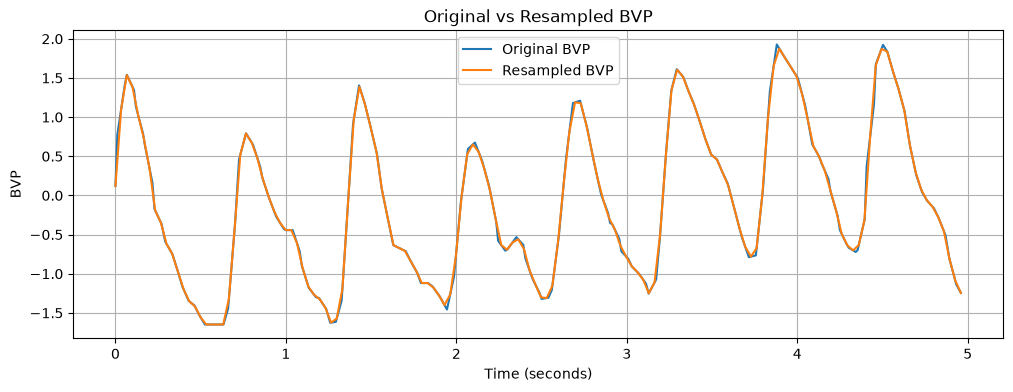

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(
    original_time,
    original_bvp,
    label="Original BVP"
)

plt.plot(
    target_time,
    bvp_resampled,
    label="Resampled BVP"
)

plt.xlabel("Time (seconds)")
plt.ylabel("BVP")
plt.title("Original vs Resampled BVP")
plt.legend()
plt.grid()

plt.show()

In [45]:
# 150 evenly spaced positions across the original video window
frame_positions = np.linspace(
    0,
    len(video_5s) - 1,
    150
)

# Select the nearest original frame
frame_indices = np.round(frame_positions).astype(int)

video_resampled = video_5s[frame_indices]

print("Original video shape:", video_5s.shape)
print("Resampled video shape:", video_resampled.shape)

print("Unique frames selected:", len(np.unique(frame_indices)))

Original video shape: (152, 480, 640, 3)
Resampled video shape: (150, 480, 640, 3)
Unique frames selected: 150


Faces detected: 1


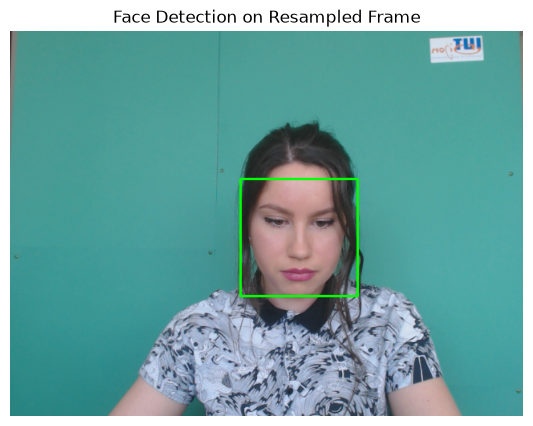

In [46]:
import cv2
import matplotlib.pyplot as plt

# Pick one frame from the 150-frame resampled video
frame = video_resampled[75]

# OpenCV uses BGR; convert for display
rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Haar cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

print("Faces detected:", len(faces))

# Display detected face
display_frame = rgb_frame.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(
        display_frame,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.figure(figsize=(8, 5))
plt.imshow(display_frame)
plt.axis("off")
plt.title("Face Detection on Resampled Frame")
plt.show()

In [47]:
import cv2
import numpy as np

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

centers = []
sizes = []
failed_frames = []

for i, frame in enumerate(video_resampled):

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    if len(faces) == 0:
        failed_frames.append(i)
        continue

    # Select largest detected face
    x, y, w, h = max(faces, key=lambda box: box[2] * box[3])

    center_x = x + w / 2
    center_y = y + h / 2

    centers.append([center_x, center_y])
    sizes.append([w, h])

centers = np.array(centers)
sizes = np.array(sizes)

print("Total frames:", len(video_resampled))
print("Successful detections:", len(centers))
print("Failed detections:", len(failed_frames))

if len(centers) > 0:
    print("\nCenter X:")
    print("Mean:", centers[:, 0].mean())
    print("Std:", centers[:, 0].std())
    print("Min:", centers[:, 0].min())
    print("Max:", centers[:, 0].max())

    print("\nCenter Y:")
    print("Mean:", centers[:, 1].mean())
    print("Std:", centers[:, 1].std())
    print("Min:", centers[:, 1].min())
    print("Max:", centers[:, 1].max())

    print("\nFace width:")
    print("Mean:", sizes[:, 0].mean())
    print("Std:", sizes[:, 0].std())

    print("\nFace height:")
    print("Mean:", sizes[:, 1].mean())
    print("Std:", sizes[:, 1].std())

Total frames: 150
Successful detections: 150
Failed detections: 0

Center X:
Mean: 357.41
Std: 4.590595458833926
Min: 344.5
Max: 360.5

Center Y:
Mean: 277.67
Std: 45.60818018733043
Min: 256.0
Max: 381.0

Face width:
Mean: 147.46
Std: 3.586325882199404

Face height:
Mean: 147.46
Std: 3.586325882199404


In [48]:
# Find frames with unusually low/high Y positions

y_centers = centers[:, 1]

median_y = np.median(y_centers)
mad_y = np.median(np.abs(y_centers - median_y))

print("Median Y:", median_y)
print("MAD:", mad_y)

# Show frames far from the median
threshold = 3 * mad_y

outlier_indices = np.where(
    np.abs(y_centers - median_y) > threshold
)[0]

print("Potential outlier frames:", outlier_indices)
print("Number of outliers:", len(outlier_indices))

for idx in outlier_indices:
    print(
        "Frame:", idx,
        "| Center Y:", y_centers[idx]
    )

Median Y: 257.25
MAD: 0.75
Potential outlier frames: [  7  32  37  46  49  56  57  58  67  68  80  81  98 100 108 123 129 130
 132 134 135 136 145 146 148]
Number of outliers: 25
Frame: 7 | Center Y: 380.0
Frame: 32 | Center Y: 379.5
Frame: 37 | Center Y: 378.0
Frame: 46 | Center Y: 379.0
Frame: 49 | Center Y: 380.0
Frame: 56 | Center Y: 379.5
Frame: 57 | Center Y: 381.0
Frame: 58 | Center Y: 380.0
Frame: 67 | Center Y: 379.5
Frame: 68 | Center Y: 379.0
Frame: 80 | Center Y: 380.5
Frame: 81 | Center Y: 380.0
Frame: 98 | Center Y: 381.0
Frame: 100 | Center Y: 379.5
Frame: 108 | Center Y: 379.0
Frame: 123 | Center Y: 380.0
Frame: 129 | Center Y: 380.0
Frame: 130 | Center Y: 380.0
Frame: 132 | Center Y: 379.0
Frame: 134 | Center Y: 379.0
Frame: 135 | Center Y: 379.0
Frame: 136 | Center Y: 379.0
Frame: 145 | Center Y: 380.0
Frame: 146 | Center Y: 380.5
Frame: 148 | Center Y: 379.0


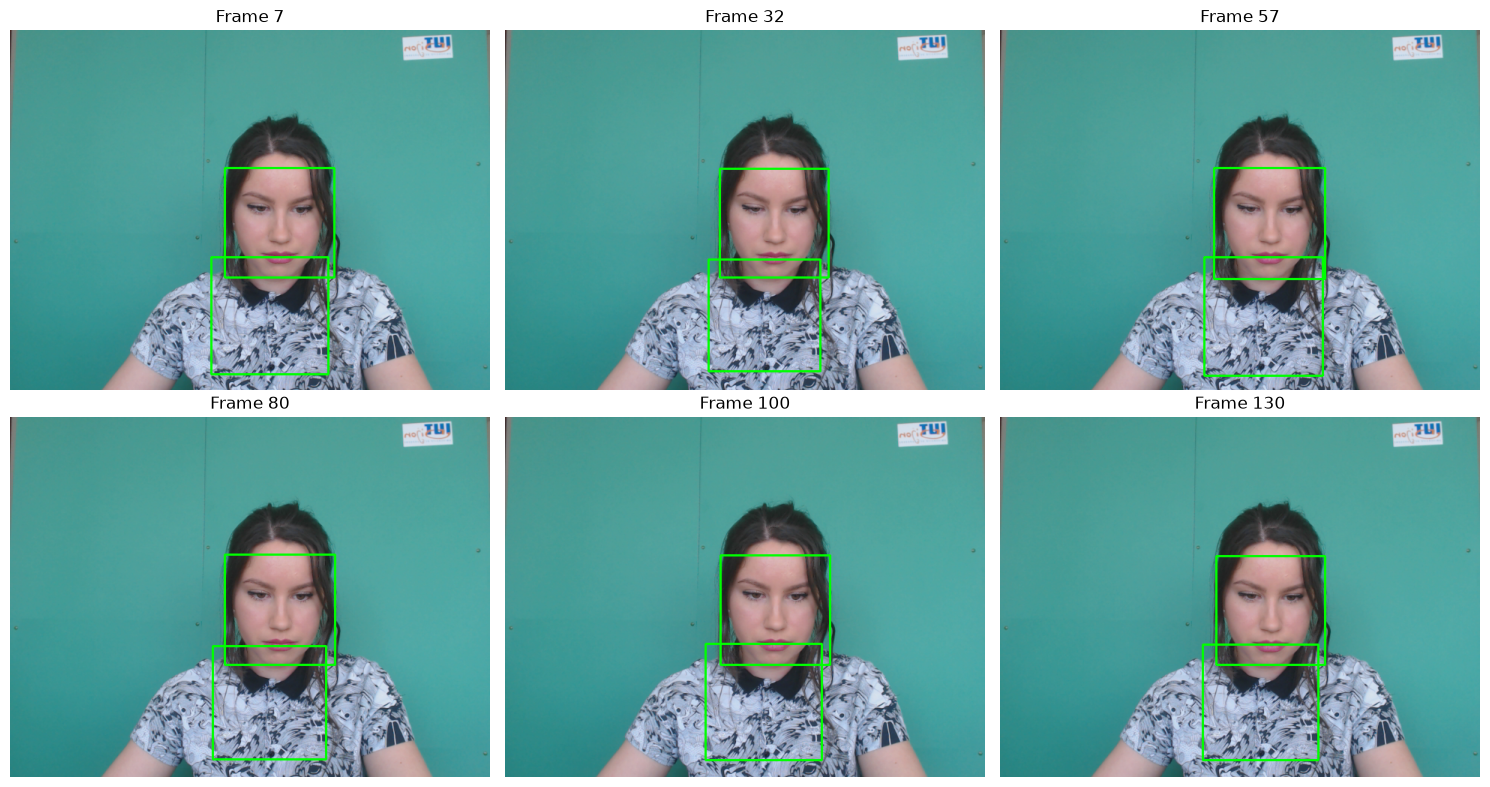

In [49]:
import matplotlib.pyplot as plt
import cv2

# Pick a few problematic frames
check_indices = [7, 32, 57, 80, 100, 130]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, idx in zip(axes.ravel(), check_indices):

    frame = video_resampled[idx]

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    display = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    for (x, y, w, h) in faces:
        cv2.rectangle(
            display,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    ax.imshow(display)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [50]:
import cv2
import numpy as np

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# ------------------------------------------------
# 1. Find the reference face in the first frame
# ------------------------------------------------

first_frame = video_resampled[0]
gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

if len(faces) == 0:
    raise RuntimeError("No face detected in first frame.")

# Use the upper/central face candidate as reference
x, y, w, h = min(
    faces,
    key=lambda box: box[1]
)

reference_center = np.array([
    x + w / 2,
    y + h / 2
])

reference_size = np.array([w, h])

print("Reference center:", reference_center)
print("Reference size:", reference_size)


# ------------------------------------------------
# 2. Track the closest face in every frame
# ------------------------------------------------

stable_boxes = []
failed_frames = []

previous_center = reference_center.copy()

for i, frame in enumerate(video_resampled):

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    if len(faces) == 0:
        stable_boxes.append(None)
        failed_frames.append(i)
        continue

    candidates = []

    for (x, y, w, h) in faces:

        center = np.array([
            x + w / 2,
            y + h / 2
        ])

        distance = np.linalg.norm(
            center - previous_center
        )

        size_difference = np.linalg.norm(
            np.array([w, h]) - reference_size
        )

        # Combined score
        score = distance + 0.5 * size_difference

        candidates.append(
            (score, x, y, w, h, center)
        )

    # Choose the candidate most consistent
    # with the previous face location
    best = min(candidates, key=lambda item: item[0])

    _, x, y, w, h, center = best

    stable_boxes.append((x, y, w, h))

    previous_center = center


# ------------------------------------------------
# 3. Remove failed detections
# ------------------------------------------------

valid_boxes = [
    box for box in stable_boxes
    if box is not None
]

valid_boxes = np.array(valid_boxes)

print("\nTotal frames:", len(video_resampled))
print("Successful tracking:", len(valid_boxes))
print("Failed frames:", len(failed_frames))


# ------------------------------------------------
# 4. Calculate stability
# ------------------------------------------------

centers = np.column_stack([
    valid_boxes[:, 0] + valid_boxes[:, 2] / 2,
    valid_boxes[:, 1] + valid_boxes[:, 3] / 2
])

widths = valid_boxes[:, 2]
heights = valid_boxes[:, 3]

print("\nStable Center X")
print("Mean:", centers[:, 0].mean())
print("Std:", centers[:, 0].std())
print("Min:", centers[:, 0].min())
print("Max:", centers[:, 0].max())

print("\nStable Center Y")
print("Mean:", centers[:, 1].mean())
print("Std:", centers[:, 1].std())
print("Min:", centers[:, 1].min())
print("Max:", centers[:, 1].max())

print("\nStable Face Width")
print("Mean:", widths.mean())
print("Std:", widths.std())

print("\nStable Face Height")
print("Mean:", heights.mean())
print("Std:", heights.std())

Reference center: [359.5 256.5]
Reference size: [147 147]

Total frames: 150
Successful tracking: 150
Failed frames: 0

Stable Center X
Mean: 359.44
Std: 0.541356321350981
Min: 358.0
Max: 360.5

Stable Center Y
Mean: 257.3066666666667
Std: 0.7388880534665286
Min: 256.0
Max: 259.0

Stable Face Width
Mean: 146.22666666666666
Std: 0.9248183004725246

Stable Face Height
Mean: 146.22666666666666
Std: 0.9248183004725246


In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Calculate one robust face box
# -----------------------------------------

valid_boxes = np.array([
    box for box in stable_boxes
    if box is not None
])

median_box = np.median(valid_boxes, axis=0).astype(int)

x, y, w, h = median_box

print("Fixed ROI box:")
print("x =", x, "y =", y, "w =", w, "h =", h)


# -----------------------------------------
# 2. Crop every frame using SAME ROI
# -----------------------------------------

rois = []

for frame in video_resampled:

    crop = frame[y:y+h, x:x+w]

    # Resize to CNN input size
    crop = cv2.resize(crop, (64, 64))

    rois.append(crop)

rois = np.array(rois)

print("\nFinal ROI shape:", rois.shape)

Fixed ROI box:
x = 286 y = 184 w = 146 h = 146

Final ROI shape: (150, 64, 64, 3)


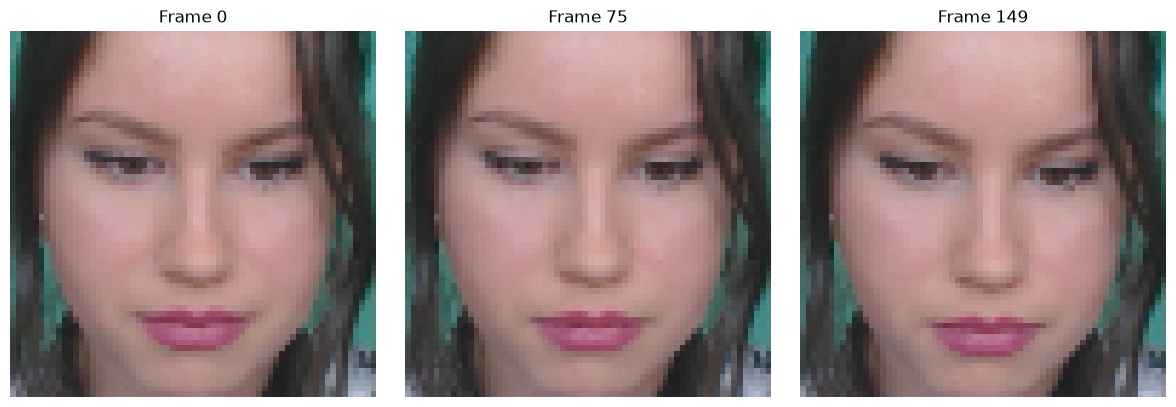

In [52]:
indices = [0, 75, 149]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, idx in zip(axes, indices):

    rgb = cv2.cvtColor(rois[idx], cv2.COLOR_BGR2RGB)

    ax.imshow(rgb)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [53]:
# Convert to float
roi_data = rois.astype(np.float32)

# Normalize pixel values: [0, 255] → [0, 1]
roi_data = roi_data / 255.0

print("After normalization:")
print("Shape:", roi_data.shape)
print("Min:", roi_data.min())
print("Max:", roi_data.max())
# (T, H, W, C) → (C, T, H, W)
roi_tensor = np.transpose(
    roi_data,
    (3, 0, 1, 2)
)

print("CNN input shape:", roi_tensor.shape)
import torch

input_tensor = torch.from_numpy(roi_tensor).unsqueeze(0)

print("Final CNN input:", input_tensor.shape)

After normalization:
Shape: (150, 64, 64, 3)
Min: 0.015686275
Max: 0.8784314
CNN input shape: (3, 150, 64, 64)
Final CNN input: torch.Size([1, 3, 150, 64, 64])


In [54]:
# Convert BVP to float32
target_bvp = np.asarray(bvp_resampled, dtype=np.float32)

print("Target BVP shape:", target_bvp.shape)
print("Target BVP min:", target_bvp.min())
print("Target BVP max:", target_bvp.max())
print("First 5 BVP values:", target_bvp[:5])
target_tensor = torch.from_numpy(target_bvp).unsqueeze(0)

print("Final target shape:", target_tensor.shape)

Target BVP shape: (150,)
Target BVP min: -1.6481824
Target BVP max: 1.8740438
First 5 BVP values: [0.12028675 1.0969512  1.5350702  1.3867966  1.0258647 ]
Final target shape: torch.Size([1, 150])


In [3]:
import torch
import torch.nn as nn

class rPPGCNN(nn.Module):
    def __init__(self, input_channels=3, output_dim=150):
        super(rPPGCNN, self).__init__()
        
        # 3D Convolutions for temporal-spatial feature extraction
        self.conv1 = nn.Conv3d(input_channels, 16, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        
        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        
        self.conv3 = nn.Conv3d(32, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2))
        
        # Fully connected layers
        # After pooling: (batch, 64, 75, 8, 8) -> flattened: 64*75*8*8 = 307200
        self.fc1 = nn.Linear(64 * 75 * 8 * 8, 256)
        self.relu_fc = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, output_dim)
    
    def forward(self, x):
        # x shape: (batch, channels, time, height, width)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected
        x = self.relu_fc(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Create model instance
model = rPPGCNN(input_channels=3, output_dim=150)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

print(f"Model created and moved to device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Move input tensor to same device
# input_tensor = input_tensor.to(device)
# target_tensor = target_tensor.to(device)

Model created and moved to device: cpu
Model parameters: 78,752,534


In [56]:
model.eval()

with torch.no_grad():
    prediction = model(input_tensor)

print("Input shape:", input_tensor.shape)
print("Prediction shape:", prediction.shape)
print("Prediction min:", prediction.min().item())
print("Prediction max:", prediction.max().item())   

Input shape: torch.Size([1, 3, 150, 64, 64])
Prediction shape: torch.Size([1, 150])
Prediction min: -0.08033184707164764
Prediction max: 0.08612968027591705


In [57]:
import torch.nn as nn

criterion = nn.MSELoss()

loss = criterion(prediction, target_tensor)

print("Initial MSE loss:", loss.item())

Initial MSE loss: 0.9399200677871704


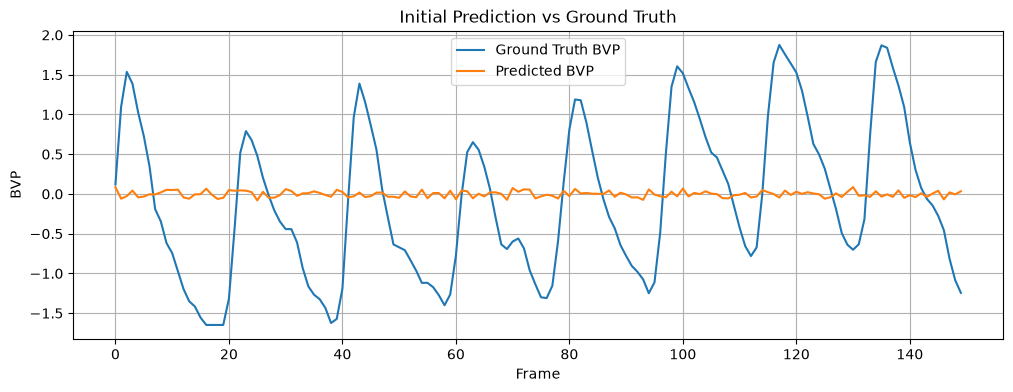

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(
    target_tensor[0].numpy(),
    label="Ground Truth BVP"
)

plt.plot(
    prediction[0].numpy(),
    label="Predicted BVP"
)

plt.xlabel("Frame")
plt.ylabel("BVP")
plt.title("Initial Prediction vs Ground Truth")

plt.legend()
plt.grid(True)
plt.show()

In [59]:
import os
import cv2
import numpy as np

# ============================================================
# SETTINGS
# ============================================================

DATASET_ROOT = r"D:\projects\RPPG\DATASET_2"

WINDOW_FRAMES = 150
TARGET_SIZE = (64, 64)

# Your existing subject split
train_subjects = [
    'subject13', 'subject5', 'subject14', 'subject34',
    'subject45', 'subject24', 'subject47', 'subject33',
    'subject8', 'subject41', 'subject30', 'subject15',
    'subject37', 'subject27', 'subject16', 'subject32',
    'subject43', 'subject44', 'subject40', 'subject17',
    'subject31', 'subject26', 'subject36', 'subject46',
    'subject38', 'subject25', 'subject22', 'subject49',
    'subject42'
]

# ============================================================
# STORAGE
# ============================================================

X_train = []
y_train = []

window_subjects = []

# ============================================================
# FACE DETECTOR
# ============================================================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

# ============================================================
# PROCESS EACH TRAINING SUBJECT
# ============================================================

for subject in train_subjects:

    subject_path = os.path.join(DATASET_ROOT, subject)

    video_path = os.path.join(subject_path, "vid.avi")
    gt_path = os.path.join(subject_path, "ground_truth.txt")

    if not os.path.exists(video_path):
        print(f"{subject}: video missing")
        continue

    if not os.path.exists(gt_path):
        print(f"{subject}: ground truth missing")
        continue

    # --------------------------------------------------------
    # Load ground truth
    # --------------------------------------------------------

    with open(gt_path, "r") as f:
        lines = f.readlines()

    bvp_original = np.array(
        [float(x) for x in lines[0].split()],
        dtype=np.float32
    )

    timestamp_original = np.array(
        [float(x) for x in lines[2].split()],
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Read video
    # --------------------------------------------------------

    cap = cv2.VideoCapture(video_path)

    frames = []

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frames.append(frame)

    cap.release()

    frames = np.array(frames)

    # --------------------------------------------------------
    # Determine number of complete 5-sec windows
    # --------------------------------------------------------

    num_windows = len(frames) // WINDOW_FRAMES

    print(
        f"{subject}: "
        f"{len(frames)} frames → "
        f"{num_windows} windows"
    )

    # --------------------------------------------------------
    # Process each window
    # --------------------------------------------------------

    for w_idx in range(num_windows):

        start = w_idx * WINDOW_FRAMES
        end = start + WINDOW_FRAMES

        video_window = frames[start:end]

        # ----------------------------------------------------
        # Corresponding BVP time interval
        # ----------------------------------------------------

        frame_times = np.linspace(
            timestamp_original[0],
            timestamp_original[-1],
            len(frames)
        )

        window_times = frame_times[start:end]

        start_time = window_times[0]
        end_time = window_times[-1]

        # Select BVP samples in same time interval
        mask = (
            (timestamp_original >= start_time) &
            (timestamp_original <= end_time)
        )

        bvp_window = bvp_original[mask]

        if len(bvp_window) < 2:
            continue

        # ----------------------------------------------------
        # Resample BVP to exactly 150 samples
        # ----------------------------------------------------

        target_times = np.linspace(
            start_time,
            end_time,
            WINDOW_FRAMES
        )

        bvp_resampled = np.interp(
            target_times,
            timestamp_original[mask],
            bvp_window
        ).astype(np.float32)

        # ----------------------------------------------------
        # Detect face in first frame
        # ----------------------------------------------------

        first_frame = video_window[0]

        gray = cv2.cvtColor(
            first_frame,
            cv2.COLOR_BGR2GRAY
        )

        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(50, 50)
        )

        if len(faces) == 0:
            print(
                f"{subject} window {w_idx}: "
                "face not detected"
            )
            continue

        # Select uppermost candidate
        x, y, fw, fh = min(
            faces,
            key=lambda box: box[1]
        )

        # ----------------------------------------------------
        # Create fixed ROI
        # ----------------------------------------------------

        roi_window = []

        for frame in video_window:

            crop = frame[
                y:y+fh,
                x:x+fw
            ]

            if crop.size == 0:
                break

            crop = cv2.resize(
                crop,
                TARGET_SIZE
            )

            crop = crop.astype(
                np.float32
            ) / 255.0

            roi_window.append(crop)

        # Make sure all 150 frames succeeded
        if len(roi_window) != WINDOW_FRAMES:
            continue

        roi_window = np.array(
            roi_window,
            dtype=np.float32
        )

        # ----------------------------------------------------
        # Convert:
        # (T,H,W,C)
        # →
        # (C,T,H,W)
        # ----------------------------------------------------

        roi_window = np.transpose(
            roi_window,
            (3, 0, 1, 2)
        )

        X_train.append(roi_window)
        y_train.append(bvp_resampled)
        window_subjects.append(subject)


# ============================================================
# FINAL ARRAYS
# ============================================================

X_train = np.array(
    X_train,
    dtype=np.float32
)

y_train = np.array(
    y_train,
    dtype=np.float32
)

print("\n================================")
print("TRAINING DATASET")
print("================================")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Number of windows:", len(X_train))
print("Unique subjects:", len(set(window_subjects)))

print(
    "Pixel range:",
    X_train.min(),
    "→",
    X_train.max()
)

print(
    "BVP range:",
    y_train.min(),
    "→",
    y_train.max()
)

subject13: 2018 frames → 13 windows
subject5: 1550 frames → 10 windows
subject14: 1993 frames → 13 windows
subject34: 2035 frames → 13 windows
subject45: 2032 frames → 13 windows
subject24: 2009 frames → 13 windows
subject47: 2023 frames → 13 windows
subject33: 1999 frames → 13 windows
subject8: 2022 frames → 13 windows
subject41: 2037 frames → 13 windows
subject30: 2028 frames → 13 windows
subject15: 2020 frames → 13 windows
subject37: 2032 frames → 13 windows
subject27: 1431 frames → 9 windows
subject16: 2050 frames → 13 windows
subject32: 2033 frames → 13 windows
subject43: 2009 frames → 13 windows
subject44: 2017 frames → 13 windows
subject40: 2028 frames → 13 windows
subject17: 2046 frames → 13 windows
subject31: 2027 frames → 13 windows
subject26: 1485 frames → 9 windows
subject36: 2052 frames → 13 windows
subject46: 1991 frames → 13 windows
subject38: 2050 frames → 13 windows
subject25: 1448 frames → 9 windows
subject22: 2032 frames → 13 windows
subject49: 2034 frames → 13 windo

In [60]:
# Statistics for every BVP window

bvp_means = np.mean(y_train, axis=1)
bvp_stds = np.std(y_train, axis=1)

print("BVP window statistics")
print("---------------------")

print("Mean of window means:", bvp_means.mean())
print("Std of window means:", bvp_means.std())

print("Mean of window stds:", bvp_stds.mean())
print("Std of window stds:", bvp_stds.std())

print("\nMinimum window std:", bvp_stds.min())
print("Maximum window std:", bvp_stds.max())

print("\nFirst 10 window means:")
print(bvp_means[:10])

print("\nFirst 10 window stds:")
print(bvp_stds[:10])

BVP window statistics
---------------------
Mean of window means: 0.003024403
Std of window means: 0.18015032
Mean of window stds: 0.95103025
Std of window stds: 0.15688978

Minimum window std: 0.4767682
Maximum window std: 1.4946587

First 10 window means:
[ 0.150535   -0.4373471  -0.14459307  0.13712922 -0.11522365  0.02979028
  0.02669159  0.11812968 -0.03223633  0.12809438]

First 10 window stds:
[0.79576796 1.0119154  0.9866235  0.94545853 0.94687724 0.9460549
 1.0064694  1.0253763  1.0611265  1.0366261 ]


In [61]:
epsilon = 1e-8

y_train_normalized = (
    y_train - np.mean(y_train, axis=1, keepdims=True)
) / (
    np.std(y_train, axis=1, keepdims=True) + epsilon
)

print("Original shape:", y_train.shape)
print("Normalized shape:", y_train_normalized.shape)

print("\nFirst window:")
print("Mean:", np.mean(y_train_normalized[0]))
print("Std :", np.std(y_train_normalized[0]))

print("\nOverall normalized range:")
print(
    y_train_normalized.min(),
    "→",
    y_train_normalized.max()
)

Original shape: (362, 150)
Normalized shape: (362, 150)

First window:
Mean: -5.086263e-08
Std : 1.0

Overall normalized range:
-2.4672503 → 4.3893642


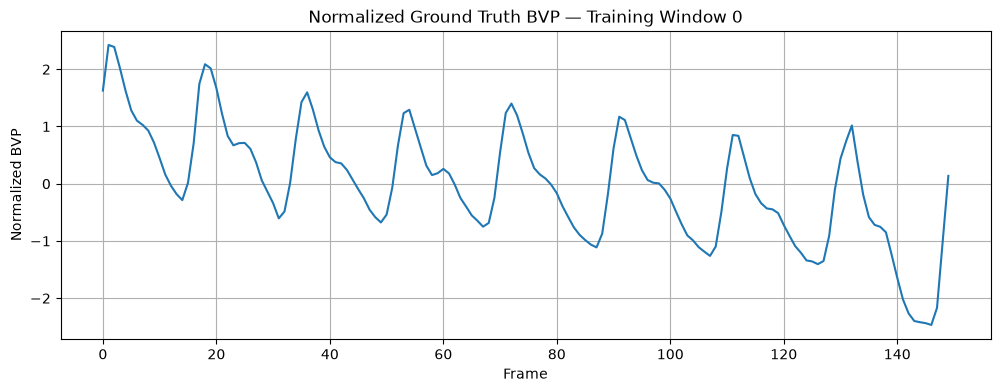

In [62]:
plt.figure(figsize=(12, 4))

plt.plot(y_train_normalized[0])

plt.xlabel("Frame")
plt.ylabel("Normalized BVP")
plt.title("Normalized Ground Truth BVP — Training Window 0")

plt.grid(True)
plt.show()

In [64]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader


def build_dataset(subjects, dataset_root, window_frames=150):

    X = []
    y = []
    subjects_used = []

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        "haarcascade_frontalface_default.xml"
    )

    for subject in subjects:

        subject_path = os.path.join(dataset_root, subject)

        video_path = os.path.join(subject_path, "vid.avi")
        gt_path = os.path.join(subject_path, "ground_truth.txt")

        if not os.path.exists(video_path):
            print(f"{subject}: video missing")
            continue

        if not os.path.exists(gt_path):
            print(f"{subject}: ground truth missing")
            continue

        # --------------------------------------------------
        # Load BVP + timestamps
        # --------------------------------------------------

        with open(gt_path, "r") as f:
            lines = f.readlines()

        bvp = np.array(
            [float(x) for x in lines[0].split()],
            dtype=np.float32
        )

        timestamps = np.array(
            [float(x) for x in lines[2].split()],
            dtype=np.float32
        )

        # --------------------------------------------------
        # Load video
        # --------------------------------------------------

        cap = cv2.VideoCapture(video_path)

        frames = []

        while True:

            ret, frame = cap.read()

            if not ret:
                break

            frames.append(frame)

        cap.release()

        frames = np.array(frames)

        # Safety check
        if len(frames) != len(bvp):
            print(
                f"{subject}: frame/BVP mismatch "
                f"{len(frames)} vs {len(bvp)}"
            )
            continue

        # --------------------------------------------------
        # Complete 5-second windows
        # --------------------------------------------------

        num_windows = len(frames) // window_frames

        print(
            f"{subject}: "
            f"{len(frames)} frames → "
            f"{num_windows} windows"
        )

        # --------------------------------------------------
        # Process windows
        # --------------------------------------------------

        for w in range(num_windows):

            start = w * window_frames
            end = start + window_frames

            video_window = frames[start:end]
            time_window = timestamps[start:end]

            # ------------------------------------------------
            # BVP corresponding to this time interval
            # ------------------------------------------------

            start_time = time_window[0]
            end_time = time_window[-1]

            mask = (
                (timestamps >= start_time) &
                (timestamps <= end_time)
            )

            bvp_window = bvp[mask]
            bvp_times = timestamps[mask]

            if len(bvp_window) < 2:
                continue

            # ------------------------------------------------
            # Resample BVP → exactly 150
            # ------------------------------------------------

            target_times = np.linspace(
                start_time,
                end_time,
                window_frames
            )

            bvp_resampled = np.interp(
                target_times,
                bvp_times,
                bvp_window
            ).astype(np.float32)

            # ------------------------------------------------
            # Detect face on first frame
            # ------------------------------------------------

            gray = cv2.cvtColor(
                video_window[0],
                cv2.COLOR_BGR2GRAY
            )

            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(50, 50)
            )

            if len(faces) == 0:
                continue

            # Choose uppermost face
            x, y0, fw, fh = min(
                faces,
                key=lambda box: box[1]
            )

            # ------------------------------------------------
            # Extract fixed ROI
            # ------------------------------------------------

            roi_window = []

            for frame in video_window:

                crop = frame[
                    y0:y0 + fh,
                    x:x + fw
                ]

                if crop.size == 0:
                    break

                crop = cv2.resize(
                    crop,
                    (64, 64)
                )

                crop = crop.astype(
                    np.float32
                ) / 255.0

                roi_window.append(crop)

            if len(roi_window) != window_frames:
                continue

            roi_window = np.array(
                roi_window,
                dtype=np.float32
            )

            # (T,H,W,C) → (C,T,H,W)
            roi_window = np.transpose(
                roi_window,
                (3, 0, 1, 2)
            )

            # ------------------------------------------------
            # Normalize target BVP
            # ------------------------------------------------

            mean = np.mean(bvp_resampled)
            std = np.std(bvp_resampled)

            bvp_normalized = (
                bvp_resampled - mean
            ) / (std + 1e-8)

            # ------------------------------------------------
            # Store
            # ------------------------------------------------

            X.append(roi_window)
            y.append(bvp_normalized)
            subjects_used.append(subject)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y, subjects_used

In [2]:
X_val, y_val, val_subjects_used = build_dataset(
    val_subjects,
    DATASET_ROOT
)

print("\n==============================")
print("VALIDATION DATASET")
print("==============================")

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print(
    "Number of windows:",
    len(X_val)
)

print(
    "Unique subjects:",
    len(set(val_subjects_used))
)


NameError: name 'build_dataset' is not defined

# CHECKPOINT: SAVE PROCESSED DATA


# CHECKPOINT: SAVE PROCESSED DATA


In [66]:
X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).float()

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

print("Validation dataset:", len(val_dataset))
print("Validation batches:", len(val_loader))

Xb, yb = next(iter(val_loader))

print("Validation input :", Xb.shape)
print("Validation target:", yb.shape)

Validation dataset: 71
Validation batches: 18
Validation input : torch.Size([4, 3, 150, 64, 64])
Validation target: torch.Size([4, 150])


In [67]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

model = model.to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# Training settings
EPOCHS = 50
PATIENCE = 8

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        prediction = model(X_batch)

        loss = criterion(
            prediction,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            prediction = model(X_batch)

            loss = criterion(
                prediction,
                y_batch
            )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # ========================================================
    # BEST MODEL
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "best_rppg_model.pth"
        )

        marker = " ★ BEST"

    else:

        patience_counter += 1
        marker = ""

    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
        f"{marker}"
    )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break


# ============================================================
# RESTORE BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(
        "best_rppg_model.pth",
        map_location=device
    )
)

print("\nTraining complete.")
print("Best validation loss:", best_val_loss)
print("Best model restored.")

Device: cpu
Epoch 01 | Train Loss: 1.009556 | Val Loss: 1.000979 ★ BEST
Epoch 02 | Train Loss: 1.001614 | Val Loss: 1.000623 ★ BEST
Epoch 03 | Train Loss: 1.001247 | Val Loss: 1.000606 ★ BEST
Epoch 04 | Train Loss: 1.001166 | Val Loss: 1.000335 ★ BEST
Epoch 05 | Train Loss: 1.000919 | Val Loss: 1.000163 ★ BEST
Epoch 06 | Train Loss: 1.000378 | Val Loss: 1.000090 ★ BEST
Epoch 07 | Train Loss: 1.000239 | Val Loss: 0.999997 ★ BEST
Epoch 08 | Train Loss: 1.000687 | Val Loss: 0.999746 ★ BEST
Epoch 09 | Train Loss: 1.000505 | Val Loss: 0.999599 ★ BEST
Epoch 10 | Train Loss: 1.000330 | Val Loss: 0.999461 ★ BEST
Epoch 11 | Train Loss: 1.000220 | Val Loss: 0.999315 ★ BEST
Epoch 12 | Train Loss: 1.000045 | Val Loss: 0.999194 ★ BEST
Epoch 13 | Train Loss: 0.999916 | Val Loss: 0.999072 ★ BEST
Epoch 14 | Train Loss: 0.999737 | Val Loss: 0.998945 ★ BEST
Epoch 15 | Train Loss: 0.999645 | Val Loss: 0.998827 ★ BEST
Epoch 16 | Train Loss: 0.999517 | Val Loss: 0.998719 ★ BEST
Epoch 17 | Train Loss: 0.999

In [6]:
# MODEL: LOAD BEST CHECKPOINT
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = rPPGCNN(input_channels=3, output_dim=150).to(device)
checkpoint_path = "best_rppg_model.pth"
model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)
model.to(device)
model.eval()

print("Device:", device)
print("Model parameter count:", sum(p.numel() for p in model.parameters()))
print("Checkpoint path:", checkpoint_path)
print("✅ Best trained model loaded successfully.")

Device: cpu
Model parameter count: 78752534
Checkpoint path: best_rppg_model.pth
✅ Best trained model loaded successfully.


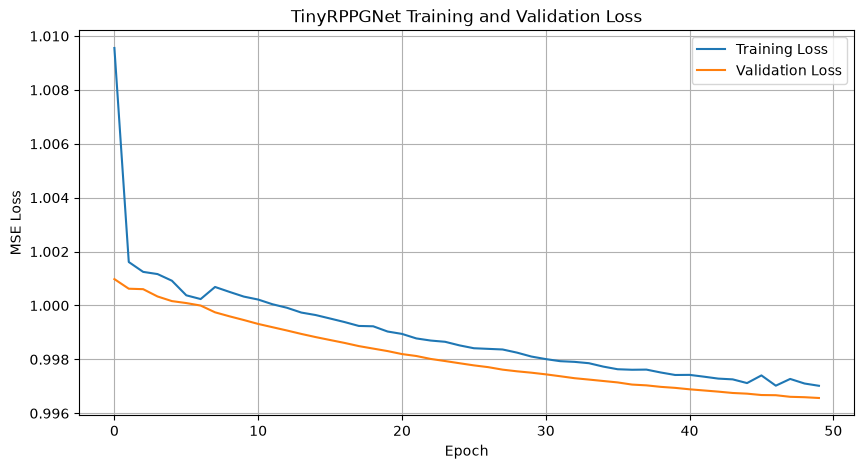

In [68]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TinyRPPGNet Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [2]:
import os

print(os.listdir("."))

['.venv', 'best_rppg_model.pth', 'DATASET_2', 'inspection', 'Number of lines.docx', 'rPPG_DeepLearning_UBFC.ipynb', 'rPPG_Project.ipynb', 'rPPG_training.ipynb', 'splits', 'Stage 1.docx']


In [1]:
# Jupyter variables disappear after a kernel restart, but the checkpoint files remain on disk.
# RECOVERY: LOAD PROCESSED DATA

import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

checkpoint_dir = "checkpoints"
required_files = [
    "rppg_X_train.npy",
    "rppg_y_train.npy",
    "rppg_y_train_normalized.npy",
    "rppg_X_val.npy",
    "rppg_y_val.npy",
    "train_window_subjects.npy",
    "val_subjects_used.npy",
]

missing = [
    name for name in required_files
    if not os.path.exists(os.path.join(checkpoint_dir, name))
]

if missing:
    for checkpoint_name in missing:
        print(f"Missing checkpoint: {checkpoint_name}")
    print("Preprocessing must be run once to generate the processed dataset before continuing.")
else:
    X_train = np.load(os.path.join(checkpoint_dir, "rppg_X_train.npy"))
    y_train = np.load(os.path.join(checkpoint_dir, "rppg_y_train.npy"))
    y_train_normalized = np.load(os.path.join(checkpoint_dir, "rppg_y_train_normalized.npy"))
    X_val = np.load(os.path.join(checkpoint_dir, "rppg_X_val.npy"))
    y_val = np.load(os.path.join(checkpoint_dir, "rppg_y_val.npy"))
    train_window_subjects = np.load(os.path.join(checkpoint_dir, "train_window_subjects.npy"))
    val_subjects_used = np.load(os.path.join(checkpoint_dir, "val_subjects_used.npy"))

    X_tensor = torch.from_numpy(X_train).float()
    y_tensor = torch.from_numpy(y_train_normalized).float()
    train_dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=False)

    X_val_tensor = torch.from_numpy(X_val).float()
    y_val_tensor = torch.from_numpy(y_val).float()
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    print("Recovered X_train:", X_train.shape)
    print("Recovered y_train:", y_train.shape)
    print("Recovered y_train_normalized:", y_train_normalized.shape)
    print("Recovered X_val:", X_val.shape)
    print("Recovered y_val:", y_val.shape)
    print("Recovered X_tensor:", X_tensor.shape)
    print("Recovered y_tensor:", y_tensor.shape)
    print("Recovered train_dataset:", len(train_dataset))
    print("Recovered train_loader batches:", len(train_loader))
    print("Recovered X_val_tensor:", X_val_tensor.shape)
    print("Recovered y_val_tensor:", y_val_tensor.shape)
    print("Recovered val_dataset:", len(val_dataset))
    print("Recovered val_loader batches:", len(val_loader))
    print("✅ Processed rPPG dataset recovered successfully.")


Missing checkpoint: rppg_X_train.npy
Missing checkpoint: rppg_y_train.npy
Missing checkpoint: rppg_y_train_normalized.npy
Missing checkpoint: rppg_X_val.npy
Missing checkpoint: rppg_y_val.npy
Missing checkpoint: train_window_subjects.npy
Missing checkpoint: val_subjects_used.npy
Preprocessing must be run once to generate the processed dataset before continuing.
